In [1]:
%reset -f
import sys, os
sys.path.insert(0, os.path.abspath("../"))

from src.models.quantum_kernel import QuantumKernel
from src.models.qsvm_model     import QSVM
from src.models.pso_qsvm       import PSOQSVM
from src.models.svm_model      import ClassicalSVM

import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

print("✅ Modüller yüklendi.")

✅ Modüller yüklendi.


In [ ]:

X_train = np.load("../data/processed/X_train.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test  = np.load("../data/processed/y_test.npy")

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"Sınıflar: {np.unique(y_train)}")

X_train : (1600, 8)  |  X_test : (400, 8)
y_train : (1600,)  |  y_test : (400,)
Sınıflar: [0 1 2 3]



KeyboardInterrupt



In [ ]:
N_QUBITS = X_train.shape[1]

qkernel = QuantumKernel()  # otomatik: 1/n_qubits

print(qkernel)

QuantumKernel(encoding=amplitude, n_features=None, n_qubits=None)


In [ ]:
print("⏳ Klasik SVM eğitiliyor...")

svm = ClassicalSVM()
svm.fit(X_train, y_train)

acc_train_svm = svm.accuracy(X_train, y_train)
acc_test_svm  = svm.accuracy(X_test,  y_test)

print(f"✅ Klasik SVM tamamlandı.")
print(f"   Train accuracy : {acc_train_svm:.4f}")
print(f"   Test  accuracy : {acc_test_svm:.4f}"),
#eğitim 0.1 sn sürdü

⏳ Klasik SVM eğitiliyor...
✅ Klasik SVM tamamlandı.
   Train accuracy : 0.6488
   Test  accuracy : 0.6625


(None,)

In [ ]:
print("⏳ QSVM eğitiliyor...")

qsvm = QSVM(quantum_kernel=qkernel)
qsvm.fit(X_train, y_train)

acc_train_qsvm = qsvm.accuracy(X_train, y_train)
acc_test_qsvm  = qsvm.accuracy(X_test,  y_test)

print(f"✅ QSVM tamamlandı.")
print(f"   Train accuracy : {acc_train_qsvm:.4f}")
print(f"   Test  accuracy : {acc_test_qsvm:.4f}")
#eğitim 30 sn sürdü

⏳ QSVM eğitiliyor...
>> QuantumKernel: 8 features → 3 qubits (dim=8)
✅ QSVM tamamlandı.
   Train accuracy : 0.6538
   Test  accuracy : 0.6525


In [ ]:
print("⏳ PSO-QSVM eğitiliyor (uzun sürebilir)...")

pso_qsvm = PSOQSVM(
    quantum_kernel=qkernel,
    n_particles=10,
    n_iters=20,
    C_min=1e-3,
    C_max=1e3,
    cv_splits=3,
    random_state=42,
)
pso_qsvm.fit(X_train, y_train)

acc_train_pso = pso_qsvm.accuracy(X_train, y_train)
acc_test_pso  = pso_qsvm.accuracy(X_test,  y_test)

print(f"✅ PSO-QSVM tamamlandı.")
print(f"   En iyi C       : {pso_qsvm.best_C:.4f}")
print(f"   Train accuracy : {acc_train_pso:.4f}")
print(f"   Test  accuracy : {acc_test_pso:.4f}")


⏳ PSO-QSVM eğitiliyor (uzun sürebilir)...


KeyboardInterrupt: 

In [ ]:
CLASS_NAMES = ["benign", "defacement", "malware", "phishing"]

y_pred_svm  = svm.predict(X_test)
y_pred_qsvm = qsvm.predict(X_test)
y_pred_pso  = pso_qsvm.predict(X_test)

print(f"Gerçek   : {y_test[:10]}")
print(f"SVM      : {y_pred_svm[:10]}")
print(f"QSVM     : {y_pred_qsvm[:10]}")
print(f"PSO-QSVM : {y_pred_pso[:10]}")

Gerçek   : [3 1 0 2 3 2 0 0 1 0]
SVM      : [3 3 3 2 0 1 0 0 1 0]
QSVM     : [3 3 3 2 0 1 0 0 1 0]
PSO-QSVM : [3 1 3 2 0 1 0 0 1 0]


In [ ]:
for title, y_pred in [
    ("Klasik SVM", y_pred_svm),
    ("QSVM",       y_pred_qsvm),
    ("PSO-QSVM",   y_pred_pso),
]:
    print("=" * 55)
    print(f"{title} — Classification Report")
    print("=" * 55)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Klasik SVM — Classification Report
              precision    recall  f1-score   support

      benign       0.71      0.68      0.69       100
  defacement       0.69      0.73      0.71       100
     malware       0.70      0.74      0.72       100
    phishing       0.63      0.58      0.60       100

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.68       400
weighted avg       0.68      0.68      0.68       400

QSVM — Classification Report
              precision    recall  f1-score   support

      benign       0.65      0.66      0.66       100
  defacement       0.67      0.70      0.69       100
     malware       0.71      0.73      0.72       100
    phishing       0.57      0.52      0.54       100

    accuracy                           0.65       400
   macro avg       0.65      0.65      0.65       400
weighted avg       0.65      0.65      0.65       400

PSO-QSVM — Classification Report
              precision    recall

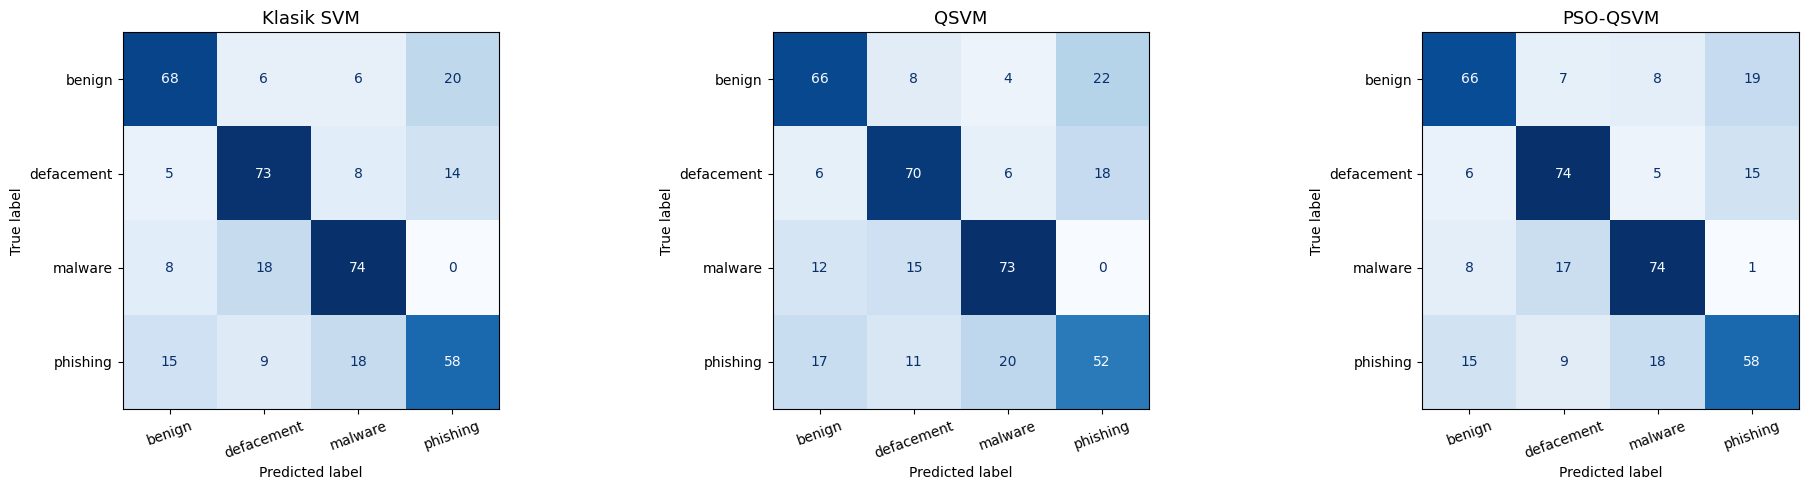

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_svm, y_pred_qsvm, y_pred_pso],
    ["Klasik SVM", "QSVM", "PSO-QSVM"],
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title, fontsize=13)
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy" : round(float(np.mean(y_true == y_pred)), 4),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Recall"   : round(recall_score   (y_true, y_pred, average="macro", zero_division=0), 4),
        "F1"       : round(f1_score       (y_true, y_pred, average="macro", zero_division=0), 4),
    }

df_results = pd.DataFrame({
    "Klasik SVM": compute_metrics(y_test, y_pred_svm),
    "QSVM"      : compute_metrics(y_test, y_pred_qsvm),
    "PSO-QSVM"  : compute_metrics(y_test, y_pred_pso),
}).T

print(df_results.to_string())

            Accuracy  Precision  Recall      F1
Klasik SVM    0.6825     0.6814  0.6825  0.6813
QSVM          0.6525     0.6501  0.6525  0.6510
PSO-QSVM      0.6800     0.6787  0.6800  0.6787


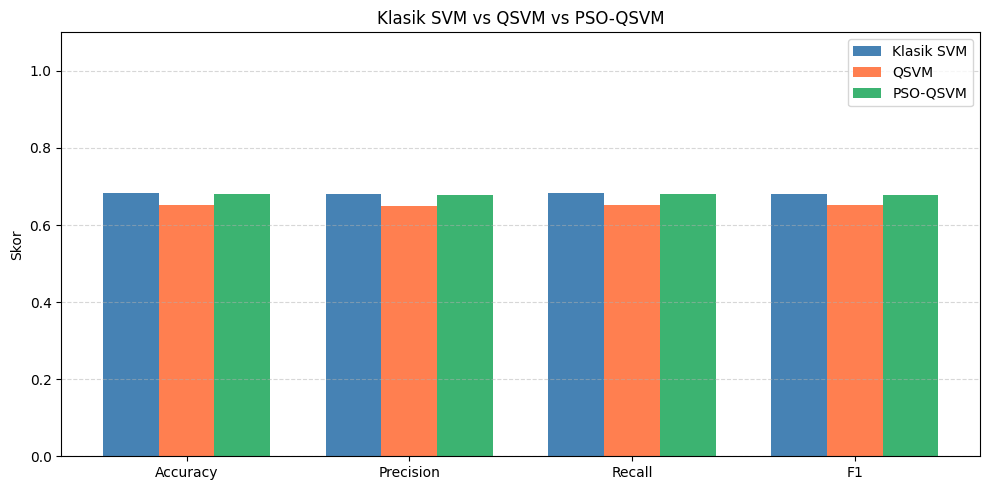

In [ ]:
metrics_list = ["Accuracy", "Precision", "Recall", "F1"]
x     = np.arange(len(metrics_list))
width = 0.25
colors = ["steelblue", "coral", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (model, color) in enumerate(zip(df_results.index, colors)):
    ax.bar(
        x + (idx - 1) * width,
        df_results.loc[model, metrics_list],
        width,
        label=model,
        color=color,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Skor")
ax.set_title("Klasik SVM vs QSVM vs PSO-QSVM")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("data/results", exist_ok=True)

np.save("data/results/y_pred_svm.npy",  y_pred_svm)
np.save("data/results/y_pred_qsvm.npy", y_pred_qsvm)
np.save("data/results/y_pred_pso.npy",  y_pred_pso)
df_results.to_csv("data/results/comparison_results.csv")

print("✅ Kaydedildi:")
print("   data/results/y_pred_svm.npy")
print("   data/results/y_pred_qsvm.npy")
print("   data/results/y_pred_pso.npy")
print("   data/results/comparison_results.csv")

✅ Kaydedildi:
   data/results/y_pred_svm.npy
   data/results/y_pred_qsvm.npy
   data/results/y_pred_pso.npy
   data/results/comparison_results.csv
